In [182]:
import yfinance as yf 

data = yf.download("AAPL", start="2015-01-01", end="2026-01-01")
signal = data['Close'].values

[*********************100%***********************]  1 of 1 completed


In [183]:
import numpy as np 
signal = signal.flatten()
noise = np.random.normal(0, 0.02 * np.std(signal), size=len(signal))
signal_with_noise = signal + noise  
signal_with_noise.flatten()
signal_with_noise.squeeze()
print(signal_with_noise.shape)

(2766,)


In [184]:
def create_dataset(signal, window_size=50):
    X, y = [], []
    
    for i in range(len(signal) - window_size):
        X.append(signal[i:i+window_size])  # μόνο slice!
        y.append(signal[i+window_size])
    
    return np.array(X), np.array(y)
X, y = create_dataset(signal_with_noise, window_size=50)

In [185]:
import torch.nn as nn 

class TDNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=16, kernel_size=3)
        self.conv2 = nn.Conv1d(in_channels=16, out_channels=32, kernel_size=3)
        self.relu = nn.ReLU()
        self.fc1 = nn.Linear(32*46,64)
        self.fc2 = nn.Linear(64,1)
        
    def forward(self,x):
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x
    
model = TDNN()

        

In [186]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [187]:
import torch.optim as optim 
import torch 
print(X.shape)
X = torch.tensor(X, dtype=torch.float32).unsqueeze(1)  # Add channel dimension: (n_samples, 50) -> (n_samples, 1, 50)
y = torch.tensor(y, dtype=torch.float32)

# Convert train/test splits to tensors
X_train = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1)
X_test = torch.tensor(X_test, dtype=torch.float32).unsqueeze(1)
y_train = torch.tensor(y_train, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
for epoch in range(10000):
    model.train()
    
    optimizer.zero_grad()
    output = model(X_train)
    loss = criterion(output.squeeze(), y_train)
    
    loss.backward()
    optimizer.step()
    
    print(f"Epoch {epoch}, Train Loss: {loss.item()}")

(2716, 50)
Epoch 0, Train Loss: 9936.1044921875
Epoch 1, Train Loss: 5534.43359375
Epoch 2, Train Loss: 3129.322021484375
Epoch 3, Train Loss: 1248.53759765625
Epoch 4, Train Loss: 193.37991333007812
Epoch 5, Train Loss: 172.64556884765625
Epoch 6, Train Loss: 904.3461303710938
Epoch 7, Train Loss: 1505.9293212890625
Epoch 8, Train Loss: 1550.5130615234375
Epoch 9, Train Loss: 1180.9578857421875
Epoch 10, Train Loss: 685.33203125
Epoch 11, Train Loss: 285.7451171875
Epoch 12, Train Loss: 81.17737579345703
Epoch 13, Train Loss: 64.72260284423828
Epoch 14, Train Loss: 169.7617950439453
Epoch 15, Train Loss: 316.1404724121094
Epoch 16, Train Loss: 439.51995849609375
Epoch 17, Train Loss: 503.2311096191406
Epoch 18, Train Loss: 497.208740234375
Epoch 19, Train Loss: 431.3847351074219
Epoch 20, Train Loss: 311.304931640625
Epoch 21, Train Loss: 188.14230346679688
Epoch 22, Train Loss: 92.93479919433594
Epoch 23, Train Loss: 52.21234130859375
Epoch 24, Train Loss: 70.5656509399414
Epoch 25, 

In [188]:
model.eval()

with torch.no_grad():
    pred = model(X_test).squeeze()
    test_loss = criterion(pred, y_test)

print("Test Loss:", test_loss.item())

Test Loss: 18.640756607055664


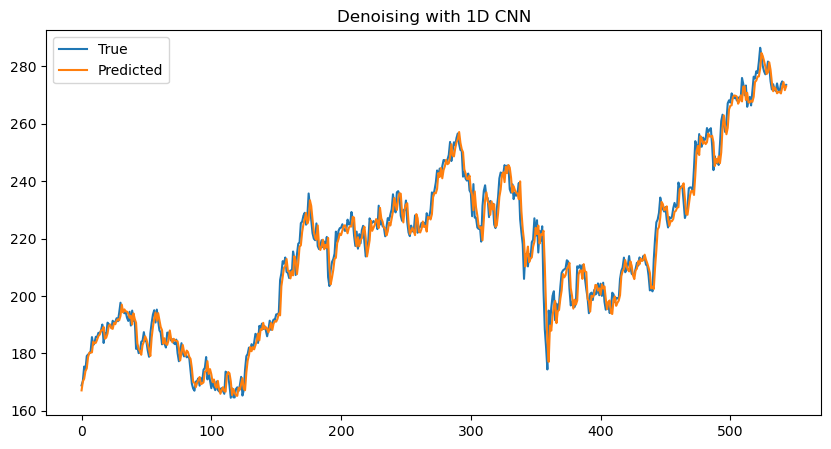

In [189]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_test.numpy(), label="True")
plt.plot(pred.numpy(), label="Predicted")
plt.legend()
plt.title("Denoising with 1D CNN")
plt.show()

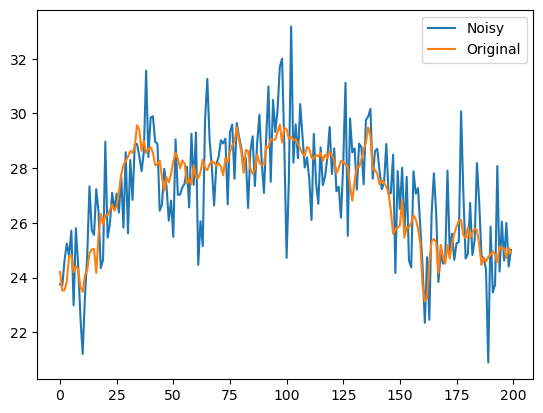

In [190]:
plt.plot(signal_with_noise[:200], label="Noisy")
plt.plot(signal[:200], label="Original")
plt.legend()
plt.show()

In [191]:
def moving_avg(signal, window=10):
    return np.convolve(signal, np.ones(window)/window, mode='same')

In [192]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test.numpy(), pred.numpy())
print("MSE:", mse)

MSE: 18.640757


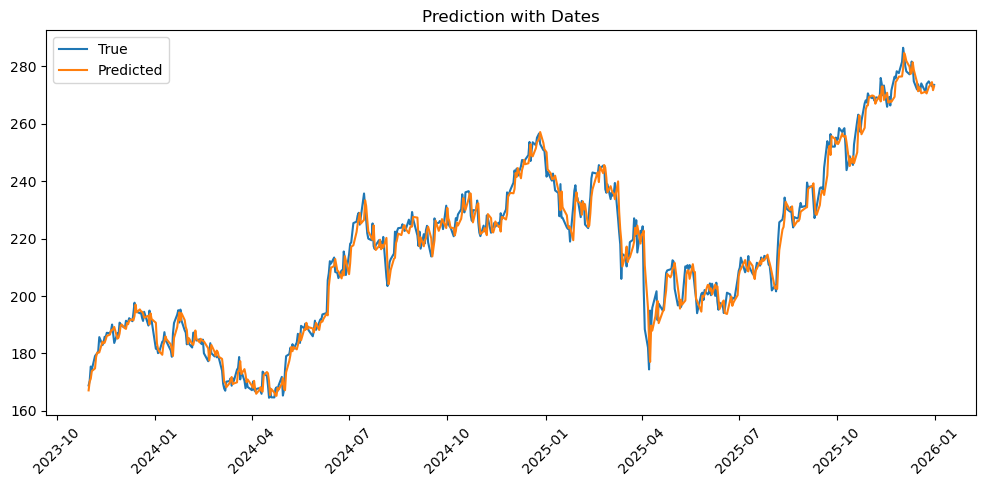

In [193]:
import matplotlib.pyplot as plt
window_size = 50
dates = data.index
dates_targets = dates[window_size:]
dates_train = dates_targets[:split]
dates_test = dates_targets[split:]
plt.figure(figsize=(12,5))

plt.plot(dates_test, y_test.numpy(), label="True")
plt.plot(dates_test, pred.numpy(), label="Predicted")

plt.legend()
plt.title("Prediction with Dates")
plt.xticks(rotation=45)
plt.show()

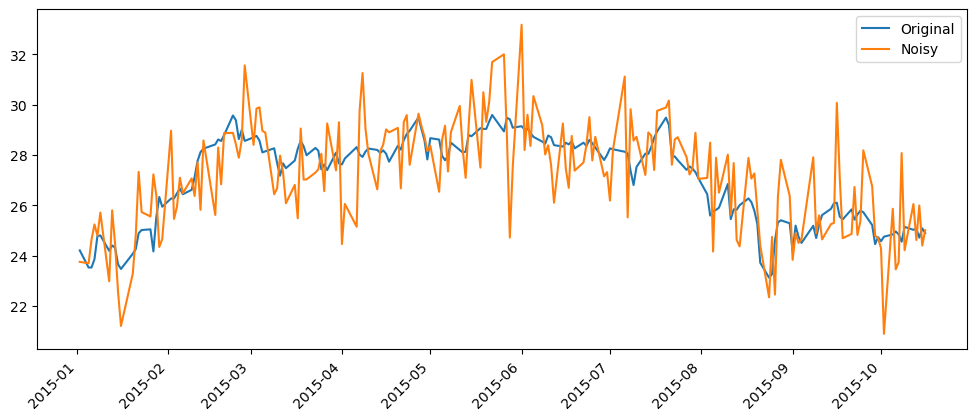

In [194]:
plt.figure(figsize=(12,5))

plt.plot(dates[:200], signal[:200], label="Original")
plt.plot(dates[:200], signal_with_noise[:200], label="Noisy")
plt.gcf().autofmt_xdate()
plt.legend()
plt.xticks(rotation=45)
plt.show()

In [195]:
plt.gcf().autofmt_xdate()

<Figure size 640x480 with 0 Axes>